In [1]:
%load_ext autoreload
%autoreload 2

# Training of depth-one QAOA parameters with an optimal beta computation per gamma

In this how-to we exemplify the efficient gamma parameter scanner where an optimal beta is computed per gamma value, used with the efficient depth-one QAOA energy computation.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

from qiskit import transpile
from qiskit.circuit.library import QAOAAnsatz

from qiskit_ibm_runtime import Sampler

from qiskit_aer import Aer

from qaoa_training_pipeline import (
    DepthOneGammaScanTrainer,
    EfficientDepthOneEvaluator,
    DepthOneScanTrainer,
)
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


To exemplify these methods we use the Maximum Cut problem on the graph $G=(V, E)$. For details regarding the Max Cut problem and the instance we are solving here, please refer to the `efficient_depth_one.ipynb` notebook.

In [3]:
graph = nx.from_edgelist([(0, 1), (0, 2), (0, 3)])
cost_op = graph_to_operator(graph, pre_factor=-0.5)
cost_op

SparsePauliOp(['IIZZ', 'IZIZ', 'ZIIZ'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j])

In the following cell we execute the depth-one one-dimensional parameter scanner. This will compute the energy over a grid of $\gamma$. For each value of $\gamma$ the optimal $\beta$ is analytically computed to maximise the energy. The parameters in the returned result are ordered as $[\beta, \gamma]$ to match the order of `QAOAAnsatz`.

In [4]:
trainer = DepthOneGammaScanTrainer(EfficientDepthOneEvaluator(), num_points=1000)
result = trainer.provide_params(cost_op)
energy = result["energy"]
print(f"energy acheived: {energy}")

energy acheived: 0.8164962950340583


Now, we check that we do indeed get good cuts by simulating the QAOA circuit with the returned optimal parameters. Note however, that we must pay attention to the order of the parameters in the Ansatz circuit when we bind them.

In [5]:
optimal_circuit = QAOAAnsatz(cost_op).decompose()
optimal_circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

In [6]:
optimal_circuit.assign_parameters(result["optimized_params"], inplace=True)
optimal_circuit.measure_all()

Use the sampler to sample candidate solutions.

In [7]:
sampler = Sampler(mode=Aer.get_backend("qasm_simulator"))
isa_circuit = transpile(optimal_circuit, basis_gates=["sx", "x", "rzz", "rz"])
sampler_result = sampler.run([isa_circuit]).result()[0].data.meas.get_counts()

We now plot the results where we see that the most probable samples are `0001` and `1110`, i.e., maximum cuts.

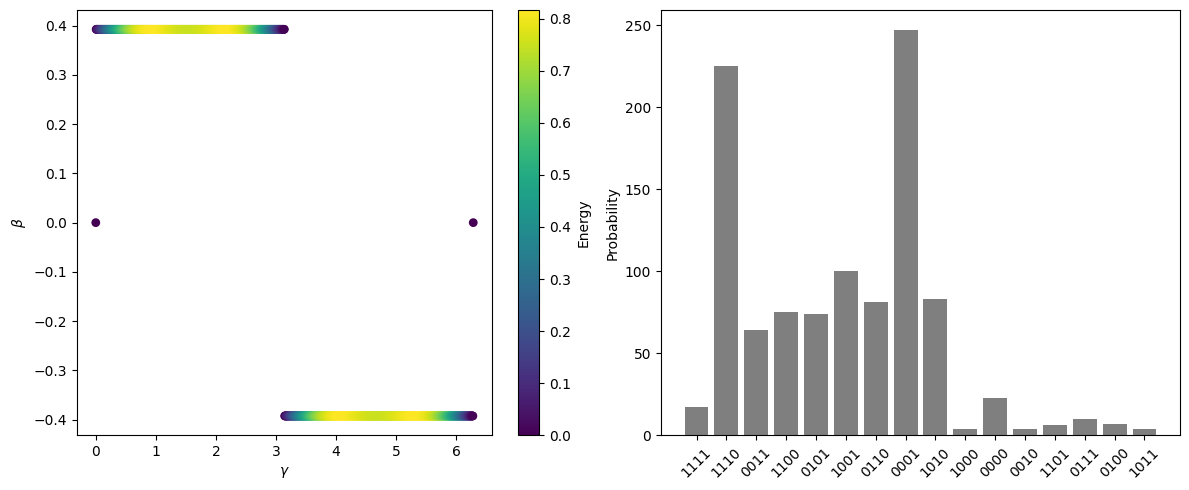

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
trainer.plot(axis=axs[0], fig=fig)
axs[1].bar(list(sampler_result.keys()), list(sampler_result.values()), color="tab:grey")
axs[1].set_ylabel("Probability")
plt.xticks(rotation=45)
plt.tight_layout()

In the plot above, we display in the beta and gamma space only the points that we evaluated (scanned for gamma) and their corresponding optimal value of beta, that was computed analytically.

Finally, we convert the energy to the average cut value. With depth-one QAOA we get a value close to 2.30. This is consitent with the fact that the maximum cut has a value of 3 and that the QAOA state has approximatively half of its probability mass on the maximum cut.

In [9]:
result["energy"] + len(graph.edges()) / 2

2.3164962950340584

We now check how the optimal beta value compares to the results of the efficient depth one scanner which scan both gamma and beta values. In the follwoing plot, we show how the optimal beta resides on the maximal energy region for each gamma value.

In [11]:
trainer_depth_one = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=20)
result_depth_one_scanner = trainer_depth_one.provide_params(cost_op)

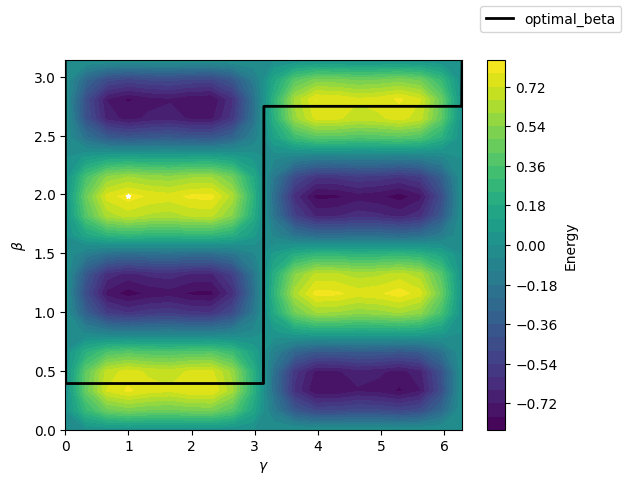

In [12]:
fig, axis = trainer_depth_one.plot()
gamma_vals = trainer._params2
beta_vals = trainer._params1
beta_vals = [x if x > 0 else x + np.pi for x in beta_vals]
line = axis.plot(gamma_vals, beta_vals, color="black", linewidth=2, label="optimal_beta")
fig.legend()